<a href="https://colab.research.google.com/github/ariqRam/sotsuken/blob/main/hands_on_patching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_id = "sbintuitions/sarashina2-7b"

tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=False)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float16,
    device_map="auto",
)

config.json:   0%|          | 0.00/559 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.97k [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B / 1.83MB            

tokenizer.model: downloading bytes:           |  0.00B            

pytorch_model.bin.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model.safetensors.index.json:   0%|          | 0.00/25.1k [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

In [2]:
model, model.device

(LlamaForCausalLM(
   (model): LlamaModel(
     (embed_tokens): Embedding(102400, 4096)
     (layers): ModuleList(
       (0-31): 32 x LlamaDecoderLayer(
         (self_attn): LlamaAttention(
           (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
           (k_proj): Linear(in_features=4096, out_features=4096, bias=False)
           (v_proj): Linear(in_features=4096, out_features=4096, bias=False)
           (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
         )
         (mlp): LlamaMLP(
           (gate_proj): Linear(in_features=4096, out_features=11008, bias=False)
           (up_proj): Linear(in_features=4096, out_features=11008, bias=False)
           (down_proj): Linear(in_features=11008, out_features=4096, bias=False)
           (act_fn): SiLUActivation()
         )
         (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
         (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
       )
     )
     (norm): LlamaRMSNorm(

In [9]:
# -------------------------------------------------------------------------
# 1. Activation Capturing Hook
# -------------------------------------------------------------------------
captured_activations = {}

def get_capture_hook(layer_name: str):
    def hook(module, input_tensor, output_tensor):
        # Decoder layer outputs are usually a tuple: (hidden_states, ...)
        hidden_states = output_tensor[0] if isinstance(output_tensor, tuple) else output_tensor
        # Detach and move to CPU to avoid VRAM overhead
        captured_activations[layer_name] = hidden_states.detach().cpu()
    return hook

# -------------------------------------------------------------------------
# 2. Activation Patching / Steering Hook
# -------------------------------------------------------------------------
# A patching hook modifies the tensor in-flight and returns the updated output.

def get_patching_hook(steering_vector: torch.Tensor, scale: float = 1.0, source_token_id=-1, base_token_id=-1):
    print("steering_vector shape:", steering_vector.shape)
    def hook(module, input_tensor, output_tensor):
        if isinstance(output_tensor, tuple):
            hidden_states = output_tensor[0]
            rest = output_tensor[1:]
        else:
            hidden_states = output_tensor
            rest = None

        # Apply intervention (e.g., add steering direction to the last token position)
        steered_states = hidden_states.clone()
        steered_states[:, base_token_id, :] = scale * steering_vector[:, source_token_id, :].to(hidden_states.device)

        if rest is not None:
            return (steered_states,) + rest
        return steered_states
    return hook

In [4]:
def get_next_token_probs(prompt):
  inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

  with torch.no_grad():
      outputs = model(**inputs)

  # Extract logits for the next token position (last token of the sequence)
  next_token_logits = outputs.logits[0, -1, :]

  # Convert logits to probabilities
  probabilities = torch.softmax(next_token_logits, dim=-1)

  # Retrieve top 5 tokens and their probabilities
  top_k = 5
  top_probs, top_indices = torch.topk(probabilities, k=top_k)

  # Display ranked distribution
  print(f"Prompt: {prompt!r}\n")
  print(f"{'Rank':<5} | {'Token':<12} | {'Token ID':<10} | {'Probability':<12}")
  print("-" * 45)

  for rank, (prob, idx) in enumerate(zip(top_probs, top_indices), start=1):
      token_str = tokenizer.decode(idx)
      print(f"{rank:<5} | {repr(token_str):<12} | {idx.item():<10} | {prob.item():.4%}")

In [12]:
target_layer_idx = 1
hook_handle = model.model.layers[target_layer_idx].register_forward_hook(
    get_capture_hook(f"layer_{target_layer_idx}")
)

# Run forward pass (prompt inference)
prompt = "「犬」の鳴き声は「"
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
print(inputs.token_to_word(0))

with torch.no_grad():
    outputs = model(**inputs)

print("Captured shape:", captured_activations[f"layer_{target_layer_idx}"].shape, captured_activations)
# Shape: [batch_size, sequence_length, hidden_dim]

# Clean up capture hook
hook_handle.remove()
hidden_dim = model.config.hidden_size
# steering_vector = torch.randn(hidden_dim, dtype=torch.float16) # altered by some random Gaussian noise
steering_vector = captured_activations[f"layer_{target_layer_idx}"]

patch_handle = model.model.layers[target_layer_idx].register_forward_hook(
    get_patching_hook(steering_vector, scale=1.0, source_token_id=1, base_token_id=1)
)

prompt = "「猫」の鳴き声は「"
try:
  get_next_token_probs(prompt)
except RuntimeError as e:
  print("RuntimeError", e)
  patch_handle.remove()

# print("\nGenerated with patch:")
# print(tokenizer.decode(output_ids[0], skip_special_tokens=True))

# # Clean up patching hook
patch_handle.remove()

0
Captured shape: torch.Size([1, 7, 4096]) defaultdict(<class 'dict'>, {'layer_1': {'mlp': tensor([[[ 0.1434, -0.3027,  0.2937,  ...,  0.0998, -0.1676,  0.0511],
         [-0.1707, -0.2246,  0.0836,  ...,  0.1456, -0.1088,  0.1901],
         [ 0.2878,  0.0444,  0.0834,  ...,  0.1136,  0.1980,  0.0811],
         ...,
         [ 0.0594,  0.0613, -0.0815,  ...,  0.2439, -0.0935,  0.0385],
         [ 0.0690, -0.0139, -0.0903,  ...,  0.1144, -0.2290,  0.0685],
         [ 0.6377, -0.0352,  0.1148,  ..., -0.0862, -0.3545,  0.0151]]],
       dtype=torch.float16), 'self_attn': tensor([[[ 0.1434, -0.3027,  0.2937,  ...,  0.0998, -0.1676,  0.0511],
         [-0.1707, -0.2246,  0.0836,  ...,  0.1456, -0.1088,  0.1901],
         [ 0.2878,  0.0444,  0.0834,  ...,  0.1136,  0.1980,  0.0811],
         ...,
         [ 0.0594,  0.0613, -0.0815,  ...,  0.2439, -0.0935,  0.0385],
         [ 0.0690, -0.0139, -0.0903,  ...,  0.1144, -0.2290,  0.0685],
         [ 0.6377, -0.0352,  0.1148,  ..., -0.0862, -0.3

In [ ]:
prompt = "「猫」の鳴き声は「"
tokenizer.tokenize(prompt)

In [ ]:
tokenizer.tokenize("「犬」の鳴き声は「")

In [ ]:
tokenizer.tokenize("猫が来た")

In [ ]:
tokenizer.tokenize("犬が来た")

In [ ]:
tokenizer.tokenize("犬の名前は")

In [ ]:
tokenizer.tokenize("猫の名前は")

layers: 100%|██████████| 32/32 [15:06<00:00, 28.32s/it]
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 12300 (\N{LEFT CORNER BRACKET}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 29483 (\N{CJK UNIFIED IDEOGRAPH-732B}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 12301 (\N{RIGHT CORNER BRACKET}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 40180 (\N{CJK UNIFIED IDEOGRAPH-9CF4}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 12365 (\N{HIRAGANA L

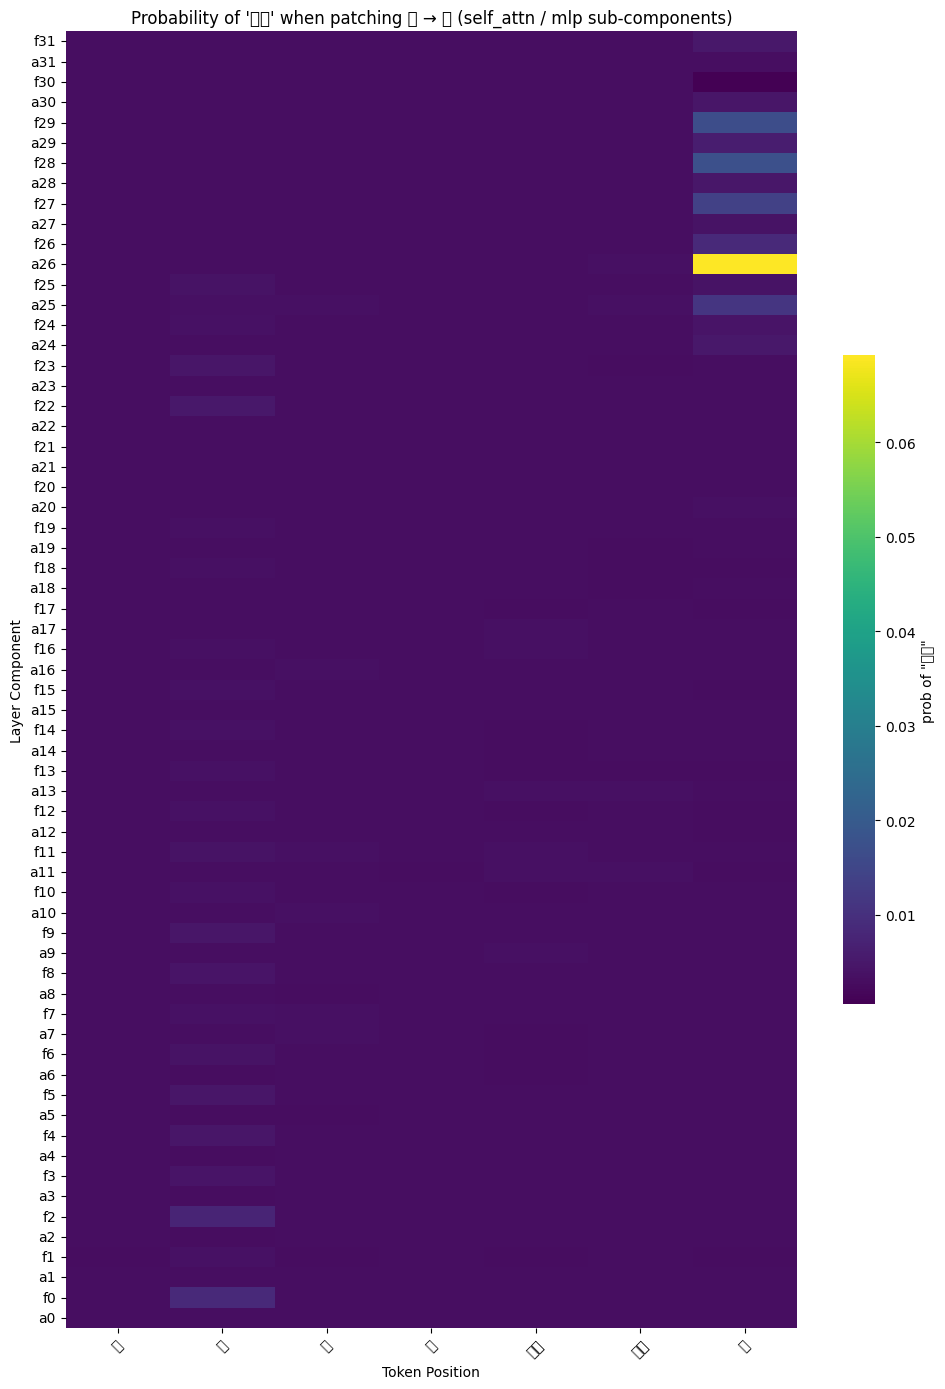

In [14]:
import time
import logging
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

# ==========================================
# 0. Logging setup
# ==========================================
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("patching")

try:
    from tqdm import tqdm
    HAS_TQDM = True
except ImportError:
    HAS_TQDM = False
    log.warning("tqdm not installed - falling back to plain periodic logging (pip install tqdm for a progress bar)")

# ==========================================
# 1. Configuration and Setup
# ==========================================
source_prompt = "「犬」の鳴き声は「"
base_prompt = "「猫」の鳴き声は「"

# NOTE: Depending on the specific LLaMA tokenizer version, this might be "ワン", "わん", or part of "ワンワン".
# You may need to run `tokenizer.tokenize("ワン")` to ensure this matches the exact token string.
target_token_str = "ワン"
_target_ids = tokenizer(target_token_str, add_special_tokens=False)["input_ids"]
if len(_target_ids) != 1:
    log.warning(
        f"'{target_token_str}' tokenizes to {len(_target_ids)} tokens {_target_ids}, "
        f"but only the first is being tracked. Consider summing probabilities over all of them."
    )
target_token_id = _target_ids[0]

num_layers = model.config.num_hidden_layers
captured_activations = defaultdict(dict)

# Set this to True to patch the WHOLE decoder layer output (residual stream) instead of
# the self_attn / mlp sub-component deltas. This is what reproduces the "dramatic" ROME-style
# curve, because it overwrites the cumulative residual state rather than a single layer's
# incremental write onto it.
PATCH_WHOLE_LAYER = False

# ==========================================
# 2. Hooks Definition
# ==========================================
def get_capture_hook(layer_name: str, component: str):
    def hook(module, input_tensor, output_tensor):
        hidden_states = output_tensor[0] if isinstance(output_tensor, tuple) else output_tensor
        captured_activations[layer_name][component] = hidden_states.detach().cpu()
    return hook

def get_patching_hook(steering_vector: torch.Tensor, pos: int):
    def hook(module, input_tensor, output_tensor):
        if isinstance(output_tensor, tuple):
            hidden_states = output_tensor[0]
            rest = output_tensor[1:]
        else:
            hidden_states = output_tensor
            rest = None

        steered_states = hidden_states.clone()
        steered_states[:, pos, :] = steering_vector[:, pos, :].to(hidden_states.device)

        if rest is not None:
            return (steered_states,) + rest
        return steered_states
    return hook

# ==========================================
# 3. Capture Phase (Run Source Prompt: 犬)
# ==========================================
log.info(f"Capture phase: running source prompt {source_prompt!r} through {num_layers} layers")
t0 = time.time()

capture_handles = []
for i in range(num_layers):
    if PATCH_WHOLE_LAYER:
        capture_handles.append(model.model.layers[i].register_forward_hook(get_capture_hook(f"layer_{i}", "whole")))
    else:
        capture_handles.append(model.model.layers[i].self_attn.register_forward_hook(get_capture_hook(f"layer_{i}", "self_attn")))
        capture_handles.append(model.model.layers[i].mlp.register_forward_hook(get_capture_hook(f"layer_{i}", "mlp")))

source_inputs = tokenizer(source_prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    model(**source_inputs)

for handle in capture_handles:
    handle.remove()

log.info(f"Capture phase done in {time.time() - t0:.2f}s")

# ==========================================
# 4. Patching Phase (Iterate over Base Prompt: 猫)
# ==========================================
base_inputs = tokenizer(base_prompt, return_tensors="pt").to(model.device)
seq_len = base_inputs.input_ids.shape[1]

assert source_inputs.input_ids.shape[1] == seq_len, "Source and base prompts must have the same number of tokens!"

if PATCH_WHOLE_LAYER:
    components = [("whole", "L")]
else:
    components = [("self_attn", "a"), ("mlp", "f")]

total_iters = num_layers * len(components) * seq_len
log.info(f"Patching phase: {num_layers} layers x {len(components)} component(s) x {seq_len} positions = {total_iters} forward passes")

results = []
best = {"prob": -1.0, "layer": None, "pos": None}
t_start = time.time()

iterator = range(num_layers)
if HAS_TQDM:
    iterator = tqdm(iterator, desc="layers")

for layer_idx in iterator:
    if PATCH_WHOLE_LAYER:
        module = model.model.layers[layer_idx]
    for comp_name, display_name in components:
        if not PATCH_WHOLE_LAYER:
            module = model.model.layers[layer_idx].self_attn if comp_name == "self_attn" else model.model.layers[layer_idx].mlp

        for pos in range(seq_len):
            steering_vector = captured_activations[f"layer_{layer_idx}"][comp_name]

            patch_handle = module.register_forward_hook(get_patching_hook(steering_vector, pos=pos))

            with torch.no_grad():
                outputs = model(**base_inputs)

            next_token_logits = outputs.logits[0, -1, :]
            probabilities = torch.softmax(next_token_logits, dim=-1)
            target_prob = probabilities[target_token_id].item()

            label = f"{display_name}{layer_idx}"
            results.append({"layer": label, "pos": pos, "prob": target_prob})

            if target_prob > best["prob"]:
                best = {"prob": target_prob, "layer": label, "pos": pos}

            patch_handle.remove()

    if not HAS_TQDM:
        done_layers = layer_idx + 1
        elapsed = time.time() - t_start
        rate = done_layers / elapsed if elapsed > 0 else 0
        eta = (num_layers - done_layers) / rate if rate > 0 else float("inf")
        log.info(
            f"layer {done_layers}/{num_layers} done | elapsed {elapsed:.1f}s | "
            f"ETA {eta:.1f}s | best so far: {best['prob']:.3%} @ {best['layer']} pos={best['pos']}"
        )

log.info(f"Patching phase done in {time.time() - t_start:.2f}s")
log.info(f"Peak probability: {best['prob']:.3%} at layer/component={best['layer']}, pos={best['pos']}")

# ==========================================
# 5. Visualization
# ==========================================
df = pd.DataFrame(results)
pivot_df = df.pivot(index="layer", columns="pos", values="prob")

def sort_key(layer_name):
    comp = layer_name[0]
    num = int(layer_name[1:])
    n_comps = len(components)
    return num * n_comps + (0 if comp == components[0][1] else 1)

pivot_df = pivot_df.reindex(sorted(pivot_df.index, key=sort_key, reverse=True))

x_labels = [tokenizer.decode(t) for t in base_inputs.input_ids[0]]

plt.figure(figsize=(10, 14))
sns.heatmap(
    pivot_df,
    cmap="viridis",
    xticklabels=x_labels,
    cbar_kws={'label': f'prob of "{target_token_str}"', 'shrink': 0.5}
)

mode_label = "whole decoder layer" if PATCH_WHOLE_LAYER else "self_attn / mlp sub-components"
plt.title(f"Probability of 'ワン' when patching 犬 → 猫 ({mode_label})")
plt.xlabel("Token Position")
plt.ylabel("Layer Component")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()